2023-11-16 19:03:43,148 - INFO - tvb_multiscale.tvb_nest.config - Configuring NEST path...
2023-11-16 19:03:43,148 - INFO - tvb_multiscale.tvb_nest.config - Configuring NEST path...
2023-11-16 19:03:43,149 - INFO - tvb_multiscale.tvb_nest.config - NEST_INSTALL_DIR: /home/docker/build/nest
2023-11-16 19:03:43,149 - INFO - tvb_multiscale.tvb_nest.config - NEST_INSTALL_DIR: /home/docker/build/nest
2023-11-16 19:03:43,151 - INFO - tvb_multiscale.tvb_nest.config - NEST_DATA_DIR: /home/docker/build/nest/share/nest
2023-11-16 19:03:43,151 - INFO - tvb_multiscale.tvb_nest.config - NEST_DATA_DIR: /home/docker/build/nest/share/nest
2023-11-16 19:03:43,151 - INFO - tvb_multiscale.tvb_nest.config - NEST_DOC_DIR: /home/docker/build/nest/share/doc/nest
2023-11-16 19:03:43,151 - INFO - tvb_multiscale.tvb_nest.config - NEST_DOC_DIR: /home/docker/build/nest/share/doc/nest
2023-11-16 19:03:43,152 - INFO - tvb_multiscale.tvb_nest.config - NEST_MODULE_PATH: /home/docker/build/nest/lib/nest
2023-11-16 19:0

Outputs' path: /home/docker/packages/tvb-multiscale/rising_net/working_files/results_cerebOFF_noise_seed_0
Config (
  title ........................................................................................... 'Config gid: 789dcc72-fab4-4708-b14d-6af34519a00e'
  Type ............................................................................................ 'Config'
  gid ............................................................................................. UUID('789dcc72-fab4-4708-b14d-6af34519a00e')
  config.gid ...................................................................................... UUID('789dcc72-fab4-4708-b14d-6af34519a00e')
  config.title .................................................................................... 'Config gid: 789dcc72-fab4-4708-b14d-6af34519a00e'
  config.log ...................................................................................... <Logger tvb_multiscale.tvb_nest.config (DEBUG)>
  config.BASEPATH .................

<Figure size 432x288 with 0 Axes>

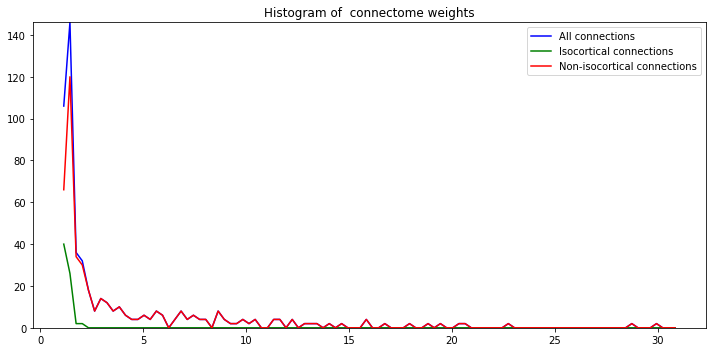

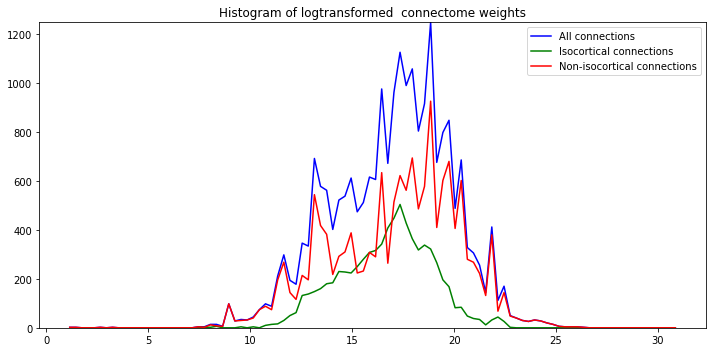

In [3]:
from rising_net.scripts.tvb_nest_script import *
from rising_net.scripts.nest_script import *        #build_NEST_network, plot_nest_results

from tvb_multiscale.core.plot.plotter import Plotter

from tvb.contrib.scripts.datatypes.time_series_xarray import TimeSeriesRegion as TimeSeriesXarray



# Assuming:
# DEFAULT_ARGS = {'G': 6.0, 'STIMULUS': 0.1,
#                 'I_e': -0.35, 'I_s': 0.085,
#                 'w_ie': -3.0, 'w_rs': -2.0,
#                 'CONN_LOG': True, 'FIC': 1.11,  'FIC_SPLIT': 0.31,  #'fit',
#                 'PRIORS_DIST': 'uniform',
#                 'output_folder': "", 'verbose': 1, 'plot_flag': True}

# config.TRANSIENT_RATIO =0.25
# # TVB - NEST interface parameters:
# config.MOSSY_MAX_RATE = 122.0  # Hz
# config.w_TVB_to_NEST = 0.04

seed = 0
test_name = 'cerebOFF'              # 'cosim', 'tvb-only', 'cerebOFF'
if test_name=='cosim':
    COMPUTE_REF = False          # True if you want to run TVB-only
    CEREB_OFF = False
elif test_name=='tvb-only':
    COMPUTE_REF = True
    CEREB_OFF = False
elif test_name == 'cerebOFF':
    COMPUTE_REF = True
    CEREB_OFF = True

resfilename = "results_%s_noise_seed_%d" % (test_name, seed)
path = os.path.join(os.getcwd(), resfilename)
# Get configuration
config, plotter = configure(output_folder=path, verbose=2)
config.SIMULATION_LENGTH = 30000.0
config.RANDOM_SEED_TVB = seed
config.RANDOM_SEED_NEST = seed

# Load and prepare connectome and connectivity with all possible normalizations:
connectome, major_structs_labels, voxel_count, inds, maps = prepare_connectome(config, plotter=plotter)
connectivity = build_connectivity(connectome, inds, config)

# # Scale up connections from principal sensory trigeminal nucleus to ansiform lobule
# reg1='Left Ansiform lobule'
# reg2='Right Ansiform lobule'
# reg3 = 'Left Principal sensory nucleus of the trigeminal'
# reg4 = 'Right Principal sensory nucleus of the trigeminal'
# reg5 = 'Left Spinal nucleus of the trigeminal'
# reg6 = 'Right Spinal nucleus of the trigeminal'
# #find the indices in region labels of these strings
# iR1 = np.where([reg1 in reg for reg in connectivity.region_labels])[0]
# iR2 = np.where([reg2 in reg for reg in connectivity.region_labels])[0]
# iR3 = np.where([reg3 in reg for reg in connectivity.region_labels])[0]
# iR4 = np.where([reg4 in reg for reg in connectivity.region_labels])[0]
# iR5 = np.where([reg5 in reg for reg in connectivity.region_labels])[0]
# iR6 = np.where([reg6 in reg for reg in connectivity.region_labels])[0]
#
# pathway_gain = 1
# '''# PST to AN
# connectivity.weights[iR1, iR3] *= pathway_gain
# connectivity.weights[iR1, iR4] *= pathway_gain
# connectivity.weights[iR2, iR3] *= pathway_gain
# connectivity.weights[iR2, iR4] *= pathway_gain
# # SNT to PST
# connectivity.weights[iR3, iR5] *= pathway_gain
# connectivity.weights[iR3, iR6] *= pathway_gain
# connectivity.weights[iR4, iR5] *= pathway_gain
# connectivity.weights[iR4, iR6] *= pathway_gain
# '''
# # SNT to AN
# connectivity.weights[iR1, iR5] *= pathway_gain
# connectivity.weights[iR1, iR6] *= pathway_gain
# connectivity.weights[iR2, iR5] *= pathway_gain
# connectivity.weights[iR2, iR6] *= pathway_gain

# # To have the full sensory whisking pathway
# reg7 = 'Left Primary somatosensory area, barrel field'
# reg8 = 'Right Primary somatosensory area, barrel field'
# iR7 = np.where([reg7 in reg for reg in connectivity.region_labels])[0]
# iR8 = np.where([reg8 in reg for reg in connectivity.region_labels])[0]
# # S1 to PST
# connectivity.weights[iR3, iR7] *= pathway_gain
# connectivity.weights[iR3, iR8] *= pathway_gain
# connectivity.weights[iR4, iR7] *= pathway_gain
# connectivity.weights[iR4, iR8] *= pathway_gain
# # SNT to S1
# connectivity.weights[iR7, iR5] *= pathway_gain
# connectivity.weights[iR7, iR6] *= pathway_gain
# connectivity.weights[iR8, iR5] *= pathway_gain
# connectivity.weights[iR8, iR6] *= pathway_gain


# # Put cereb weights to 0 if CEREB_OFF
# if CEREB_OFF:
#     #reg1='Cerebell*'
#     reg1='Left Cerebellar Cortex'
#     reg2='Left Cerebellar Nuclei'
#     reg3='Left Ansiform lobule'
#     reg4='Left Interposed nucleus'
#     reg5='Right Cerebellar Cortex'
#     reg6='Right Cerebellar Nuclei'
#     reg7='Right Ansiform lobule'
#     reg8='Right Interposed nucleus'
#     #find the indices in region labels of these strings
#     iR1 = np.where([reg1 in reg for reg in connectivity.region_labels])[0]
#     iR2 = np.where([reg2 in reg for reg in connectivity.region_labels])[0]
#     iR3 = np.where([reg3 in reg for reg in connectivity.region_labels])[0]
#     iR4 = np.where([reg4 in reg for reg in connectivity.region_labels])[0]
#     iR5 = np.where([reg5 in reg for reg in connectivity.region_labels])[0]
#     iR6 = np.where([reg6 in reg for reg in connectivity.region_labels])[0]
#     iR7 = np.where([reg7 in reg for reg in connectivity.region_labels])[0]
#     iR8 = np.where([reg8 in reg for reg in connectivity.region_labels])[0]
#     # for reg1, reg2, sc in config.BRAIN_CONNECTIONS_TO_SCALE:
#     #     iR1 = np.where([reg in reg1 for reg in connectivity.region_labels])[0]
#     #     iR2 = np.where([reg in reg2 for reg in connectivity.region_labels])[0]
#     #     connectivity.weights[iR1, iR2] *= 0
#     #iR1
#     connectivity.weights.shape
#     for i in [iR1, iR2, iR3, iR4, iR5, iR6, iR7, iR8]:
#         connectivity.weights[i,:]=0
#         connectivity.weights[:,i]=0
#                         # , iR2, iR3, iR4, iR5, iR6, iR7, iR8] = 0
#     connectivity.weights[iR1,:]


# # Prepare model
# model = build_model(connectivity.number_of_regions, inds, maps, config)

# # Prepare simulator
# simulator = build_simulator(connectivity, model, inds, maps, config, plotter=plotter)

# if COMPUTE_REF:
#     # Run simulation and get results for reference values
#     results, transient = simulate(simulator, config)
# else:
#     # Build TVB-NEST interfaces
#     nest_network, nest_nodes_inds, neuron_models, neuron_number = build_NEST_network(config)
#     simulator, nest_network = build_tvb_nest_interfaces(simulator, nest_network, nest_nodes_inds, config)
#     # Simulate TVB-NEST model
#     results, transient, simulator, nest_network = simulate_tvb_nest(simulator, nest_network, config)
        
# print(results)
       

        
# Target values: ansilob=-0.3263, interposed=-0.3209, oliv=-0.3284


In [2]:
# # Compute coherence
# transient = config.TRANSIENT_RATIO * config.SIMULATION_LENGTH
# if config.RAW_PERIOD > config.DEFAULT_DT:
#     transient = (transient // config.RAW_PERIOD) * config.RAW_PERIOD + config.RAW_PERIOD/2

# # results = plot_tvb(transient, inds,
# #                    results=results, simulator=simulator, plotter=plotter, config=config, write_files=True)

In [3]:
# import pickle
# results_path = os.path.join(config.out.FOLDER_RES, '%s.pickle' % resfilename)
# with open(results_path, 'wb') as handle:
#    pickle.dump(results, handle)
# print(results_path)
# # results = pickle.load(results_path, 'rb'))  # to load results

In [4]:
# cohfilename = "coherence_30sec_%s_noise_seed_%d" % (test_name, seed)
# coherence_path = os.path.join(config.out.FOLDER_RES, '%s.pickle' % cohfilename)
# # Save coherence
# CxyR = results["CxyR_M1_S1"]
# fR = results["fR"]
# CxyL = results["Cxyl_M1_S1"]
# fL = results["fL"]
# with open(coherence_path, 'wb') as handle:
#     pickle.dump([CxyR, fR, fL, CxyL], handle)
# print(coherence_path)

In [5]:
! pwd

/home/docker/packages/tvb-multiscale/rising_net/working_files


In [4]:
import glob
import pickle
import os
from rising_net.utils import *
from rising_net.plot_utils import *

THETA = [3, 10]
GAMMA = [25, 45]

BASEPATH = "/home/docker/packages/tvb-multiscale/rising_net/working_files/outputs" 

TASKINDS = np.sort(np.concatenate([inds["m1"], inds["s1brl"], 
                                   inds["m1thal"], inds["s1brlthal"], 
                                   inds["trigeminal"], inds["ponsmotor"], inds["ponssens"], 
                                   inds["cereb"]]))

test_name = "cosim"

Ps = []
Cs = []
CsTheta = []
CsGamma = []
for path in glob.glob(BASEPATH + "/results*%s*/res" % test_name):
    resultsfile = os.path.join(path, "source_ts.pkl")
    with open(resultsfile, 'rb') as handle:
        source_ts = pickle.load(handle)  # to load results
    Pxx_den, Cxy, f, ij = compute_selected_spectra_coherence(
                        source_ts["time_series"], TASKINDS,
                        transient=source_ts["time_series"].shape[0]-2**15, # 2**15 final length
                        sample_period=source_ts["sample_period"], 
                        nperseg=512, fmin=0.0, fmax=50.0)
    Ps.append(Pxx_den)
    Cs.append(Cxy)

Ps = np.array(Ps)
Cs = np.array(Cs)
fth = np.where(np.logical_and(f > THETA[0], f < THETA[1]))[0]
CsTheta = Cs[:, :, fth].mean(axis=2)
fgamma = np.where(np.logical_and(f > THETA[0], f < THETA[1]))[0]
CsGamma = Cs[:, :, fgamma].mean(axis=2)

In [7]:
print([Ps.shape, Cs.shape, CsTheta.shape, CsGamma.shape])
print(f)

[(10, 22, 25), (10, 231, 25), (10, 231), (10, 231)]
[ 1.953125  3.90625   5.859375  7.8125    9.765625 11.71875  13.671875
 15.625    17.578125 19.53125  21.484375 23.4375   25.390625 27.34375
 29.296875 31.25     33.203125 35.15625  37.109375 39.0625   41.015625
 42.96875  44.921875 46.875    48.828125]


<AxesSubplot:>

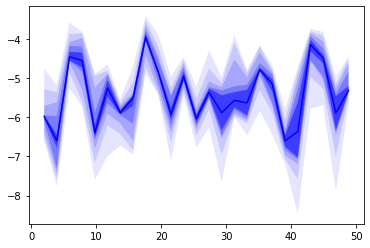

In [5]:
percent_plot(f, Cs[:, 0, :].squeeze(), percentile_min=10, percentile_max=90, n=5,
             plot_mean=False, plot_median=True,
             color='b', alpha=0.5, mode="semilog", ax=None)  # , **line_kwargs

In [ ]:
connectivity.region_labels[TASKINDS]

In [10]:
connectivity.region_labels[TASKINDS[ij]]

array([['Right Primary motor area',
        'Right Primary somatosensory area, barrel field'],
       ['Right Primary motor area',
        'Right Specific Thalamus to Primary motor area'],
       ['Right Primary motor area',
        'Right Specific Thalamus to Primary somatosensory area, barrel field'],
       ['Right Primary motor area', 'Right Pons Sensory'],
       ['Right Primary motor area',
        'Right Principal sensory nucleus of the trigeminal'],
       ['Right Primary motor area', 'Right Pons Motor'],
       ['Right Primary motor area',
        'Right Spinal nucleus of the trigeminal'],
       ['Right Primary motor area', 'Right Inferior olivary complex'],
       ['Right Primary motor area', 'Right Ansiform lobule'],
       ['Right Primary motor area', 'Right Cerebellar Nuclei'],
       ['Right Primary motor area', 'Left Primary motor area'],
       ['Right Primary motor area',
        'Left Primary somatosensory area, barrel field'],
       ['Right Primary motor area',
   

In [ ]:
ij